In [ ]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [84]:
df_da_us = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'United States')
].copy()

In [85]:
# Drop rows where salary_year_avg is missing (optional, if needed)
df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

# Explode the job_skills column
df_da_us_exploded = df_da_us.explode('job_skills')

# Preview
df_da_us_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [86]:
df_da_skills = df_da_us_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False) 
df_da_skills = df_da_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
da_job_count = len(df_da_us)
df_da_skills['skill_percent'] = (df_da_skills['skill_count'] / da_job_count) * 100

skill_percent = 5
df_da_skills_high_demand = df_da_skills[df_da_skills['skill_percent'] > skill_percent]
df_da_skills


,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
couchbase,1,160515.0,0.022989
chainer,1,100000.0,0.022989
chef,1,85000.0,0.022989


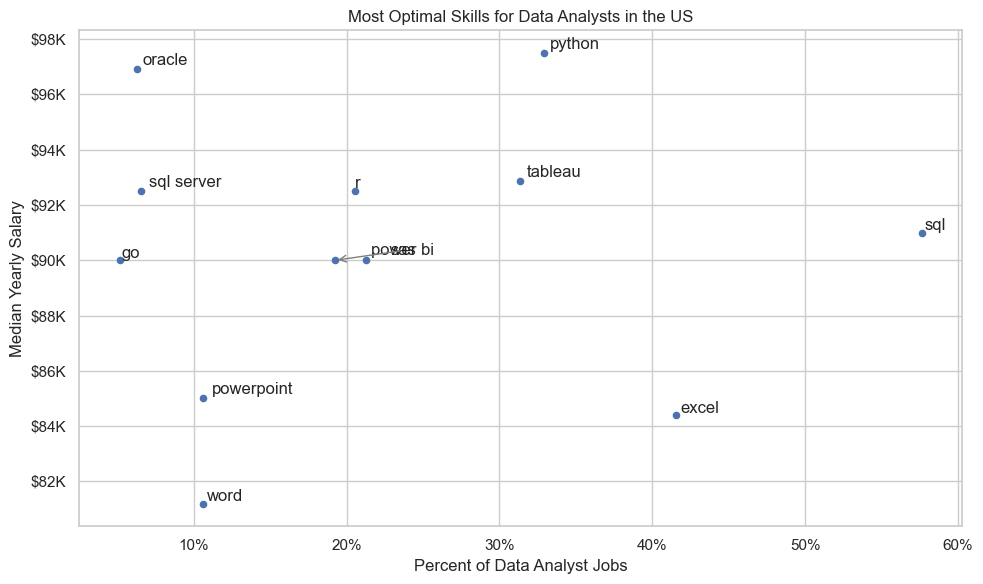

In [87]:
from adjustText import adjust_text
import matplotlib.pyplot as plt

# Scatter plot
df_da_skills_high_demand.plot(
    kind='scatter', x='skill_percent', y='median_salary', figsize=(10,6)
)

# Add text labels
texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(
        plt.text(
            df_da_skills_high_demand['skill_percent'].iloc[i],
            df_da_skills_high_demand['median_salary'].iloc[i],
            txt
        )
    )

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'), expand_points=(1.2,1.2))

# Labels and title
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

In [88]:
import ast

# Copy the job_type_skills column
df_technology = df['job_type_skills'].copy()

# Remove duplicates
df_technology = df_technology.drop_duplicates()

# Remove NaN values
df_technology = df_technology.dropna()

# Combine all dictionaries into one
technology_dict = {}

for row in df_technology:
    # Convert string to dictionary
    row_dict = ast.literal_eval(row)
    
    for key, value in row_dict.items():
        if key in technology_dict:
            # If key already exists, add values to the existing list
            technology_dict[key] += value
        else:
            # If key does not exist, add key and value
            technology_dict[key] = value

# Remove duplicates by converting values to set and back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

# Show the final dictionary
technology_dict

{'analyst_tools': ['power bi',
  'nuix',
  'powerbi',
  'microstrategy',
  'ms access',
  'sap',
  'spreadsheet',
  'sas',
  'ssis',
  'sharepoint',
  'sheets',
  'datarobot',
  'visio',
  'dax',
  'cognos',
  'looker',
  'excel',
  'outlook',
  'splunk',
  'powerpoint',
  'word',
  'alteryx',
  'qlik',
  'msaccess',
  'tableau',
  'ssrs',
  'esquisse',
  'spss'],
 'programming': ['swift',
  'bash',
  'scala',
  'assembly',
  'cobol',
  'perl',
  'julia',
  'python',
  'c',
  'f#',
  'delphi',
  'objective-c',
  'html',
  'visual basic',
  'golang',
  'go',
  'shell',
  'r',
  'sas',
  'crystal',
  'lua',
  'c#',
  'matlab',
  'ruby',
  'lisp',
  'vba',
  'dart',
  'vb.net',
  'javascript',
  'nosql',
  'apl',
  'java',
  'php',
  'css',
  'no-sql',
  'rust',
  'fortran',
  'mongodb',
  't-sql',
  'haskell',
  'visualbasic',
  'typescript',
  'mongo',
  'solidity',
  'c++',
  'clojure',
  'sql',
  'sass',
  'groovy',
  'ocaml',
  'pascal',
  'erlang',
  'elixir',
  'powershell',
  'kot

In [89]:
df_techonlogy = pd. DataFrame(list(technology_dict.items()), columns=['technology',
'skills'])
df_technology = df_technology. explode('skills')

df_technology

0         {'analyst_tools': ['power bi', 'tableau'], 'pr...
1         {'analyst_tools': ['dax'], 'cloud': ['azure'],...
2         {'cloud': ['aws'], 'libraries': ['tensorflow',...
3         {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
4         {'cloud': ['gcp'], 'programming': ['python', '...
                                ...                        
177557    {'analyst_tools': ['power bi', 'tableau', 'wor...
177558    {'analyst_tools': ['looker', 'tableau', 'splun...
177559    {'cloud': ['bigquery'], 'libraries': ['gdpr'],...
177560    {'cloud': ['bigquery', 'aws'], 'libraries': ['...
177561    {'os': ['linux', 'unix'], 'other': ['kubernete...
Name: job_type_skills, Length: 177562, dtype: str

In [90]:
df_technology_df = pd.DataFrame([
    {'skills': key, 'related_technologies': value} 
    for key, value in technology_dict.items()
])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter, FuncFormatter

# Use Seaborn theme for cleaner look
sns.set_theme(style='whitegrid')

plt.figure(figsize=(12,7))

# Scatter plot with color per technology
scatter = sns.scatterplot(
    data=df_da_skills_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology',  # color by technology
    s=120,           # larger points
    edgecolor='w',   # white border
    palette='tab10'  # consistent colors
)

# Prepare labels
texts = []
for i, row in df_da_skills_high_demand.iterrows():
    texts.append(
        plt.text(
            row['skill_percent'],
            row['median_salary'],
            row['job_skills'],
            fontsize=9
        )
    )

# Adjust labels to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
    expand_points=(1.2,1.2),
    expand_text=(1.2,1.2)
)

# Axes formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

# Legend outside
plt.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `technology` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1200x700 with 0 Axes>